### Premier League Match Analysis
The Premier League is the top tier football/soccer competition in England, widely considered to be the most important league in the world.
The objective of this project is to analyze match results from different seasons

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('premier-league-data.csv')

In [3]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   4560 non-null   object 
 1   away_team   4560 non-null   object 
 2   home_goals  4560 non-null   float64
 3   away_goals  4560 non-null   float64
 4   result      4560 non-null   object 
 5   season      4560 non-null   object 
dtypes: float64(2), object(4)
memory usage: 213.9+ KB


### Data Cleaning

##### Remove invalid values from the season column
Identify invalid values in the season column and replace them with the string Unknown season (data imputation).

In [9]:
df['season'].value_counts()

season
2006-2007    380
2007-2008    380
2008-2009    380
2009-2010    380
2010-2011    380
2011-2012    380
2012-2013    380
2013-2014    380
2014-2015    380
2015-2016    380
2016-2017    380
2017-2018    380
Name: count, dtype: int64

In [11]:
#there doesn't seem to be any invalid values from the season column.

##### Identify invalid values in goals scored

Analyze the columns home_goals and away_goals and answer: how many invalid values each contains?

<Axes: >

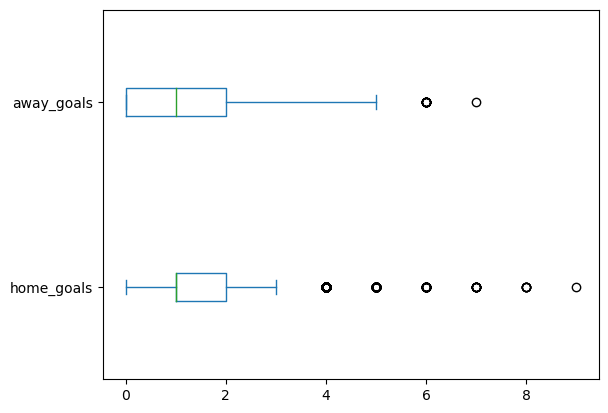

In [13]:
df[['home_goals', 'away_goals']].plot(kind='box', vert=False)

In [23]:
(df['home_goals'] < 0).sum()

0

In [24]:
(df['away_goals'] < 0).sum()

0

##### Replace invalid goals for 0
Replace all the invalid goals in home_goals and away_goals with 0 (data imputation).

In [26]:
df.loc[df['home_goals'] < 0, 'home_goals'] = 0
df.loc[df['away_goals'] < 0, 'away_goals'] = 0

##### Identify and clean invalid results in the result column (if any)
The result column contains a "summary" of the result of the match. H indicates a home win; A indicates an away win; D indicates a draw.

In [27]:
df['result'].value_counts()

result
H    2108
A    1288
D    1164
Name: count, dtype: int64

In [28]:
df.loc[df['home_goals'] == df['away_goals'], 'result'] = 'D'
df.loc[df['home_goals'] > df['away_goals'], 'result'] = 'H'
df.loc[df['home_goals'] < df['away_goals'], 'result'] = 'A'

### Analysis

##### What's the average number of goals per match?
Calculate the average number of goals per match.

In [29]:
(df['home_goals'] + df['away_goals']).mean()

2.6875

##### Create a new column total_goals
For the previous activity, it would have been convenient to have a total_goals column with the sum of home_goals and away_goals.

In [30]:
df['total_goals'] = df['home_goals'] + df['away_goals']

##### Calculate average goals per season
Calculate the number of average goals per season. 

In [31]:
goals_per_season = df.groupby('season')['total_goals'].mean().sort_index()
goals_per_season

season
2006-2007    2.450000
2007-2008    2.636842
2008-2009    2.478947
2009-2010    2.771053
2010-2011    2.797368
2011-2012    2.805263
2012-2013    2.797368
2013-2014    2.768421
2014-2015    2.565789
2015-2016    2.700000
2016-2017    2.800000
2017-2018    2.678947
Name: total_goals, dtype: float64

##### What's the biggest goal difference in a match?
What was the biggest goal difference in a match found in the dataset?

In [33]:
(df['home_goals'] - df['away_goals']).abs().sort_values(ascending=False).head(1)

1265    8.0
dtype: float64

##### What's the team with most away wins?
Find the team that has won the most matches away from home.

In [34]:
df.loc[df['result'] == 'A', 'away_team'].value_counts().head()

away_team
Chelsea              123
Manchester United    119
Arsenal              103
Manchester City      100
Liverpool             98
Name: count, dtype: int64

In [35]:
# Or
df.groupby('away_team').apply(lambda rows: (rows['result'] == 'A').sum()).sort_values(ascending=False).head()

away_team
Chelsea              123
Manchester United    119
Arsenal              103
Manchester City      100
Liverpool             98
dtype: int64

##### What's the team with the most goals scored at home?

In [36]:
df.groupby('home_team')['home_goals'].sum().sort_values(ascending=False).head()

home_team
Manchester City      501.0
Manchester United    495.0
Chelsea              491.0
Arsenal              479.0
Liverpool            466.0
Name: home_goals, dtype: float64

##### What's the team that received the least amount of goals while playing at home?

In [37]:
away_goals_df = df.groupby('home_team')[['result', 'away_goals']].agg(
    {'result': 'size', 'away_goals': 'sum'}
).sort_values(
    by=['result', 'away_goals'], ascending=[False, True]
).rename(columns={'result': 'games_played', 'away_goals': 'goals_received'})

away_goals_df['ratio'] = away_goals_df['goals_received'] / away_goals_df['games_played']


In [38]:
away_goals_df

,games_played,goals_received,ratio
home_team,,,
Manchester United,228,160.0,0.701754
Liverpool,228,182.0,0.798246
Arsenal,228,185.0,0.811404
Chelsea,228,186.0,0.815789
Manchester City,228,192.0,0.842105
Tottenham Hotspur,228,219.0,0.960526
Everton,228,238.0,1.043860
West Ham United,209,281.0,1.344498
Stoke City,190,213.0,1.121053


In [39]:
away_goals_df['ratio'].sort_values()

home_team
Manchester United           0.701754
Liverpool                   0.798246
Arsenal                     0.811404
Chelsea                     0.815789
Manchester City             0.842105
Tottenham Hotspur           0.960526
Birmingham City             1.017544
Everton                     1.043860
Charlton Athletic           1.052632
Sheffield United            1.105263
Stoke City                  1.121053
Southampton                 1.131579
Leicester City              1.144737
Burnley                     1.157895
Blackburn Rovers            1.175439
Portsmouth                  1.184211
Middlesbrough               1.184211
Aston Villa                 1.231579
Sunderland                  1.242105
Swansea City                1.278195
Norwich City                1.289474
Newcastle United            1.294737
Fulham                      1.296053
Huddersfield Town           1.315789
Brighton and Hove Albion    1.315789
Crystal Palace              1.315789
Bolton Wanderers            

##### What's the team with most goals scored playing as a visitor (away from home)?

In [40]:
away_goals_df = df.groupby('away_team')[['result', 'away_goals']].agg(
    {'result': 'size', 'away_goals': 'sum'}
).sort_values(
    by=['result', 'away_goals'], ascending=[False, False]
).rename(columns={'result': 'games_played', 'away_goals': 'goals_scored'})

away_goals_df['ratio'] = away_goals_df['goals_scored'] / away_goals_df['games_played']

In [41]:
away_goals_df.head()

,games_played,goals_scored,ratio
away_team,,,
Arsenal,228,382.0,1.675439
Manchester United,228,372.0,1.631579
Chelsea,228,368.0,1.614035
Manchester City,228,365.0,1.600877
Liverpool,228,351.0,1.539474


In [43]:
away_goals_df.sort_values('ratio', ascending=False)

,games_played,goals_scored,ratio
away_team,,,
Arsenal,228,382.0,1.675439
Manchester United,228,372.0,1.631579
Chelsea,228,368.0,1.614035
Manchester City,228,365.0,1.600877
Liverpool,228,351.0,1.539474
Tottenham Hotspur,228,342.0,1.500000
Blackpool,19,25.0,1.315789
Leicester City,76,99.0,1.302632
Reading,57,65.0,1.140351
